# Simulation Method Validation and PSS Window Sticker

This notebook is analysis-only. Run `examples/IBM_QAOA/run_job.sh` or `examples/IBM_QAOA/run_job_small.sh` first to generate the IBM QAOA campaign artifacts, then load and analyze them here.


In [1]:
# Analysis imports
import importlib
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from src.utils import (
    apply_shared_approx_axis,
    concat_summary,
    cross_strategy_envelope,
    curve_from_training_summary,
    curve_from_window_summary,
    curve_label,
    load_multi_strategy_summaries,
    plot_method_curves,
    plot_multi_method_window_sticker_components,
    plot_parameter_prescriptions_by_resource,
    prepare_monotone_curve,
    save_current_plot,
    shared_approx_ylim as compute_shared_approx_ylim,
    shared_approx_yticks as compute_shared_approx_yticks,
    window_sticker_curve_colors,
    window_sticker_method_color,
)
from src.simulation_validation import (
    build_resource_frontier_from_exact_points,
    build_binned_budget_dataset,
    build_strategy_budget_summary,
    estimate_hardware_time_per_shot,
    run_stochastic_benchmark_pss,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams.update({
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.titlesize': 16,
    'figure.titlesize': 16,
})

%load_ext autoreload
%autoreload 2

In [2]:
# Analysis configuration
GRAPH_TYPE = 'heavy_hex'
NUM_NODES = 144
REPO_ROOT = Path('../../..').resolve()
WORKSPACE_ROOT = REPO_ROOT.parent
QAOA_PARAMETER_SETTING_ROOT = Path(
    os.environ.get('QAOA_PARAMETER_SETTING_ROOT', WORKSPACE_ROOT / 'QAOA-Parameter-Setting')
).expanduser().resolve()
HARDWARE_RESULTS_ROOT = QAOA_PARAMETER_SETTING_ROOT / 'data' / 'hardware'

from src import simulation_validation as ibm_qaoa_sim_validation
ibm_qaoa_sim_validation = importlib.reload(ibm_qaoa_sim_validation)
estimate_hardware_time_per_shot = ibm_qaoa_sim_validation.estimate_hardware_time_per_shot
RESULT_TAG = 'heavy_hex_144_FA_no_opt_p6_expanded'
RESULT_JOB_P_MATCH = re.search(r'_p(\d+)', RESULT_TAG)
RESULT_JOB_P = int(RESULT_JOB_P_MATCH.group(1)) if RESULT_JOB_P_MATCH else None
INCLUDE_PT_TRANSFER_COST = True
PT_TRANSFER_COST_SECONDS = None  # None uses measured transfer lookup time from PT raw rows.
SHOW_WINDOW_STICKER_CI = False
SKIP_MISSING_MULTI_STRATEGY_SUMMARIES = True

TIME_PER_SHOT = estimate_hardware_time_per_shot(
    HARDWARE_RESULTS_ROOT,
    graph_type=GRAPH_TYPE,
    num_nodes=NUM_NODES,
    job_p=RESULT_JOB_P,
    statistic='median',
    normalize_by_pubs=True,
)
COMPARISON_RESULT_TAGS = [
    'heavy_hex_144_FA_PP_opt_p5_expanded',
    'heavy_hex_144_FA_PP_opt_p6_expanded',
    'heavy_hex_144_FA_PP_opt_p7_expanded',
    'heavy_hex_144_LR_opt_p5_expanded',
    'heavy_hex_144_I_p7_expanded',
    'heavy_hex_144_PT_p7_expanded',
    'heavy_hex_144_PT_p6_expanded',
    'heavy_hex_144_PT_p5_expanded',
    'heavy_hex_144_PT_p3_expanded',
    'heavy_hex_144_PT_p2_expanded',
    'heavy_hex_144_FA_no_opt_p2_expanded',
    'heavy_hex_144_FA_no_opt_p3_expanded',
    'heavy_hex_144_FA_no_opt_p4_expanded',
    'heavy_hex_144_FA_no_opt_p6_expanded',
]

BS_BOOTSTRAP_RANGE = range(10, 51, 10)
TRAIN_TEST_SPLIT_FRACTION = 0.5

OUTPUT_ROOT = Path(f'../results/pss_window_sticker/{RESULT_TAG}').resolve()
WINDOW_STICKER_DIR = OUTPUT_ROOT / 'window_sticker'
PLOT_DIR = OUTPUT_ROOT / 'notebook_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FRONTIER_PATH = OUTPUT_ROOT / 'pss_exp_raw_frontier.pkl'
STRATEGY_EXACT_PATH = OUTPUT_ROOT / 'strategy_raw_points.pkl'
LEGACY_FA_EXACT_PATH = OUTPUT_ROOT / 'fa_raw_points.pkl'
TRANSFER_EXACT_PATH = OUTPUT_ROOT / 'transfer_raw_points.pkl'
LEGACY_PT_EXACT_PATH = OUTPUT_ROOT / 'pt_raw_points.pkl'
TRAIN_SPECS_PATH = OUTPUT_ROOT / 'train_instance_specs.csv'
TEST_SPECS_PATH = OUTPUT_ROOT / 'test_instance_specs.csv'
CODEBOOK_PATH = OUTPUT_ROOT / 'ws_codebooks.json'
FRONTIER_PREVIEW_PATH = OUTPUT_ROOT / 'frontier_preview.csv'
FRONTIER_SUMMARY_PATH = OUTPUT_ROOT / 'frontier_group_summary.csv'

In [3]:
# Load campaign artifacts generated by the terminal script
raw_exact_paths = []
for primary_path, legacy_path in [
    (STRATEGY_EXACT_PATH, LEGACY_FA_EXACT_PATH),
    (TRANSFER_EXACT_PATH, LEGACY_PT_EXACT_PATH),
]:
    raw_path = primary_path if primary_path.exists() else legacy_path
    if raw_path.exists() and raw_path not in raw_exact_paths:
        raw_exact_paths.append(raw_path)

missing_paths = [path for path in [CODEBOOK_PATH] if not path.exists()]
if not raw_exact_paths:
    missing_paths.append(f'{STRATEGY_EXACT_PATH} or {TRANSFER_EXACT_PATH}')
if missing_paths:
    missing = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'Missing campaign artifacts. Run examples/IBM_QAOA/run_job.sh or '
        'examples/IBM_QAOA/run_job_small.sh first:\n' + missing
    )

exact_frames = [pd.read_pickle(path) for path in raw_exact_paths]
exact_df = pd.concat(exact_frames, ignore_index=True)
ws_codebooks = json.loads(CODEBOOK_PATH.read_text(encoding='utf-8'))

for col in ['N', 'M', 'Q']:
    if col not in exact_df.columns:
        exact_df[col] = 0
    exact_df[col] = pd.to_numeric(exact_df[col], errors='coerce').fillna(0.0)

if 'p' in exact_df.columns:
    exact_p_values = sorted(
        pd.to_numeric(exact_df['p'], errors='coerce').dropna().round().astype(int).unique().tolist()
    )
else:
    exact_p_values = [RESULT_JOB_P] if RESULT_JOB_P is not None else []
TIME_PER_SHOT_BY_P = {}
for p_value in exact_p_values:
    try:
        TIME_PER_SHOT_BY_P[int(p_value)] = estimate_hardware_time_per_shot(
            HARDWARE_RESULTS_ROOT,
            graph_type=GRAPH_TYPE,
            num_nodes=NUM_NODES,
            job_p=int(p_value),
            statistic='median',
            normalize_by_pubs=True,
        )
    except (FileNotFoundError, ValueError):
        TIME_PER_SHOT_BY_P[int(p_value)] = TIME_PER_SHOT

if 'p' in exact_df.columns and TIME_PER_SHOT_BY_P:
    p_for_proxy = pd.to_numeric(exact_df['p'], errors='coerce').round().astype('Int64')
    exact_df['_hardware_time_per_shot'] = p_for_proxy.map(TIME_PER_SHOT_BY_P).astype(float)
    exact_df['_hardware_time_per_shot'] = exact_df['_hardware_time_per_shot'].fillna(TIME_PER_SHOT)
else:
    exact_df['_hardware_time_per_shot'] = TIME_PER_SHOT

training_shot_cost_proxy = exact_df['N'] * exact_df['M'] * exact_df['_hardware_time_per_shot']

# --- Interpolation recursive-refinement correction ---
# I_MPSAer.json has three trainer stages:
#   Stage 1: DepthOneScanTrainer  → replaced by MPSAerSampleEvaluator (p=1, shot-based) ✓ counted
#   Stage 2: ScipyTrainer         → replaced by MPSAerSampleEvaluator (p=1, COBYLA N iters) ✓ counted
#   Stage 3: RecursionTrainer     → uses MPSAerEvaluator (exact MPS, no .shots) for p=2..target
#
# _augment_stage_result sets training_shots_used=0 whenever evaluator.shots is absent,
# so stage 3's (p-1) sub-depths each running 50 COBYLA iterations × M shots contribute
# zero to total_training_shots — and therefore zero to the N×M×t_shot formula above.
#
# Correction: add the missing hardware-equivalent cost for the recursive sub-depths.
#   extra shots per row = (p - 1) × RECURSIVE_MAXITER × M
# where RECURSIVE_MAXITER=50 is hardcoded in I_MPSAer.json's inner ScipyTrainer.
_INTERP_STRATEGY_NAMES = {'I_MPSAer', 'I_PP', 'I_MPS', 'I_SV'}
_INTERP_RECURSIVE_MAXITER = 50  # maxiter in I_MPSAer.json RecursionTrainer → ScipyTrainer
_interp_mask = pd.Series(False, index=exact_df.index)
if 'strategy' in exact_df.columns:
    _interp_mask = exact_df['strategy'].astype(str).isin(_INTERP_STRATEGY_NAMES)
if _interp_mask.any():
    _p_interp = pd.to_numeric(exact_df.loc[_interp_mask, 'p'], errors='coerce').fillna(1.0).clip(lower=1.0)
    _recursive_shots = (_p_interp - 1) * _INTERP_RECURSIVE_MAXITER * exact_df.loc[_interp_mask, 'M']
    _recursive_cost = (_recursive_shots * exact_df.loc[_interp_mask, '_hardware_time_per_shot']).values
    training_shot_cost_proxy = training_shot_cost_proxy.copy()
    training_shot_cost_proxy.loc[_interp_mask] += _recursive_cost
    _ex = exact_df.loc[_interp_mask].iloc[0]
    _ep = int(pd.to_numeric(_ex.get('p', 7), errors='coerce') or 7)
    _em = float(_ex.get('M', 100))
    _et = float(_ex['_hardware_time_per_shot'])
    print(
        f'Interp recursive correction applied to {_interp_mask.sum()} rows. '
        f'Example (p={_ep}, M={_em:.0f}): +'
        f'{(_ep - 1) * _INTERP_RECURSIVE_MAXITER * _em * _et:.4g} s added to training cost.'
    )

# Detect PT/transfer strategies by name. Use alphanumeric-only boundaries (not \b, which
# treats underscore as a word character) so that 'PT' in '_opt' does NOT match — strategy
# names like 'FA_PP_opt' and 'LR_opt' both contain the substring 'pt' but are not PT strategies.
_PT_PATTERN = (
    r'(?<![a-zA-Z0-9])PT(?![a-zA-Z0-9])'
    r'|Param\.? Transfer|Parameter Transfer'
    r'|(?<![a-zA-Z0-9])transfer(?![a-zA-Z0-9])'
)
transfer_strategy_mask = pd.Series(False, index=exact_df.index)
for transfer_col in ['strategy', 'strategy_family', 'method_label', 'strategy_runtime_label']:
    if transfer_col in exact_df.columns:
        transfer_strategy_mask |= exact_df[transfer_col].astype(str).str.contains(
            _PT_PATTERN,
            case=False,
            regex=True,
            na=False,
        )

pt_transfer_cost_proxy = pd.Series(0.0, index=exact_df.index)
if INCLUDE_PT_TRANSFER_COST and transfer_strategy_mask.any():
    if PT_TRANSFER_COST_SECONDS is None:
        if 'runtime_train_wallclock' in exact_df.columns:
            measured_transfer = pd.to_numeric(exact_df['runtime_train_wallclock'], errors='coerce').fillna(0.0)
        elif 'classical_setup_cost' in exact_df.columns:
            measured_transfer = pd.to_numeric(exact_df['classical_setup_cost'], errors='coerce').fillna(0.0)
        else:
            measured_transfer = pd.Series(0.0, index=exact_df.index)
        pt_transfer_cost_proxy.loc[transfer_strategy_mask] = measured_transfer.loc[transfer_strategy_mask]
    else:
        pt_transfer_cost_proxy.loc[transfer_strategy_mask] = float(PT_TRANSFER_COST_SECONDS)

exact_df['classical_setup_cost_proxy'] = pt_transfer_cost_proxy
exact_df['training_cost_proxy'] = training_shot_cost_proxy + pt_transfer_cost_proxy
exact_df['sampling_cost_proxy'] = exact_df['Q'] * exact_df['_hardware_time_per_shot']
exact_df['T_proxy'] = exact_df['training_cost_proxy'] + exact_df['sampling_cost_proxy']
exact_df['T_exact_proxy'] = exact_df['T_proxy']

stored_frontier_df = pd.read_pickle(FRONTIER_PATH) if FRONTIER_PATH.exists() else pd.DataFrame()
budget_grid_points = int(stored_frontier_df['T'].nunique()) if not stored_frontier_df.empty else 1000

frontier_df = build_resource_frontier_from_exact_points(
    exact_df,
    codebooks=ws_codebooks,
    num_bins=budget_grid_points,
    budget_col='T_proxy',
    scale='log',
)

train_specs_df = pd.read_csv(TRAIN_SPECS_PATH) if TRAIN_SPECS_PATH.exists() else pd.DataFrame()
test_specs_df = pd.read_csv(TEST_SPECS_PATH) if TEST_SPECS_PATH.exists() else pd.DataFrame()
frontier_preview_df = frontier_df.head(30).copy()
frontier_summary_df = frontier_df.groupby(['split', 'strategy'], as_index=False).agg(
    n_rows=('instance', 'size'),
    min_T=('T', 'min'),
    max_T=('T', 'max'),
    best_response=('BestApproximationRatio', 'max'),
)

print('Loaded campaign from:', OUTPUT_ROOT.relative_to(REPO_ROOT))
print(f'Hardware-derived TIME_PER_SHOT: {TIME_PER_SHOT:.12g} s from {HARDWARE_RESULTS_ROOT.relative_to(WORKSPACE_ROOT)} (job_p={RESULT_JOB_P})')
print('Hardware-derived TIME_PER_SHOT_BY_P:', TIME_PER_SHOT_BY_P or {'default': TIME_PER_SHOT})
print('Raw exact artifacts:', [path.name for path in raw_exact_paths])
print(f'Transfer strategy mask fires on {transfer_strategy_mask.sum()} / {len(transfer_strategy_mask)} rows '
      f'({sorted(exact_df.loc[transfer_strategy_mask, "strategy"].unique()) if transfer_strategy_mask.any() else []})')
if INCLUDE_PT_TRANSFER_COST and transfer_strategy_mask.any():
    pt_transfer_values = pt_transfer_cost_proxy.loc[transfer_strategy_mask]
    print(
        'PT transfer preprocessing cost in proxy: '
        f'median={pt_transfer_values.median():.6g} s, '
        f'min={pt_transfer_values.min():.6g} s, '
        f'max={pt_transfer_values.max():.6g} s'
    )
print('Exact rows:', len(exact_df))
print('T_proxy range: [{:.6g}, {:.6g}] s'.format(exact_df['T_proxy'].min(), exact_df['T_proxy'].max()))
print('Clean proxy binned frontier rows:', len(frontier_df))
print('Clean proxy budget bins used:', frontier_df['T'].nunique())
print('Strategies:', sorted(frontier_df['strategy'].dropna().unique()))
print('Splits:', sorted(frontier_df['split'].dropna().unique()))

Loaded campaign from: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded
Hardware-derived TIME_PER_SHOT: 0.000275788483796 s from <workspace>/QAOA-Parameter-Setting/data/hardware (job_p=6)
Hardware-derived TIME_PER_SHOT_BY_P: {6: 0.00027578848379629633}
Raw exact artifacts: ['transfer_raw_points.pkl']
Transfer strategy mask fires on 0 / 390 rows ([])
Exact rows: 390
T_proxy range: [0.0275788, 137.894] s
Clean proxy binned frontier rows: 30000
Clean proxy budget bins used: 1000
Strategies: ['FA_PP_no_opt']
Splits: ['test', 'train']


## T_proxy resource accounting

The resource axis $T_{\text{proxy}}$ is the estimated hardware time to run the strategy once on a real device:

$$T_{\text{proxy}} = \underbrace{t_{\text{preprocess}}}_{\text{classical setup}} + \underbrace{N \cdot M \cdot t_{\text{shot}}}_{\text{training shots}} + \underbrace{Q \cdot t_{\text{shot}}}_{\text{sampling shots}}$$

$t_{\text{shot}}$ is estimated from real IBM hardware results (`data/hardware/heavy_hex/`) at the corresponding circuit depth $p$.

### Method-specific adjustments

| Method | Adjustment |
|--------|-----------|
| **FA\*, LR** | No adjustment. $N \times M$ is the total training shots at depth $p$. |
| **PT (Param. Transfer)** | Adds measured classical preprocessing time $t_{\text{preprocess}}$ (parameter lookup). |
| **Interpolation (I\_MPSAer)** | See below. |

### Interpolation recursive-refinement correction

`I_MPSAer.json` has three trainer stages:

1. **`DepthOneScanTrainer` + `ScipyTrainer` at $p=1$** — both replaced by `MPSAerSampleEvaluator` by the PSS campaign builder, so these cost $N \times M$ hardware-equivalent shots. Already counted in the base formula.

2. **`RecursionTrainer` for $p = 2 \ldots p_{\text{target}}$** — uses `MPSAerEvaluator`, an *exact* MPS expectation-value evaluator with no `.shots` attribute. `_augment_stage_result` therefore records `training_shots_used = 0` for every sub-depth, making these $(p-1)$ depths invisible to the base formula.

Each sub-depth runs an inner `ScipyTrainer` with `maxiter = 50` (hardcoded in `I_MPSAer.json`) and $M$ shots per evaluation. The missing hardware-equivalent cost is:

$$\Delta T_{\text{recursive}} = (p - 1) \times 50 \times M \times t_{\text{shot}}$$

This correction is added to `training_shot_cost_proxy` before computing $T_{\text{proxy}}$. For $p = 7$, $M = 100$: $\Delta T \approx 6 \times 50 \times 100 \times 298\,\mu\text{s} \approx 8.9\,\text{s}$, shifting the Interp curves significantly to the right relative to an uncorrected accounting.

In [4]:
# Quick artifact preview
def _relativize_paths(df, cols, base):
    df = df.copy()
    def _rel(p):
        if not pd.notna(p):
            return p
        try:
            return str(Path(p).resolve().relative_to(base))
        except ValueError:
            # Not under `base` (e.g. an instance loaded straight from a
            # sibling repo outside WORKSPACE_ROOT) -- leave it unscrubbed
            # rather than crash; this is a display convenience only.
            return str(p)
    for col in cols:
        if col in df.columns:
            df[col] = df[col].apply(_rel)
    return df

_path_cols = ['graph_path', 'minmax_path']
display(_relativize_paths(train_specs_df, _path_cols, WORKSPACE_ROOT).head(10))
display(_relativize_paths(test_specs_df, _path_cols, WORKSPACE_ROOT).head(10))
display(frontier_preview_df)
display(frontier_summary_df)


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,100,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
1,heavy_hex,144,101,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
2,heavy_hex,144,102,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
3,heavy_hex,144,103,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
4,heavy_hex,144,104,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
5,heavy_hex,144,105,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
6,heavy_hex,144,106,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
7,heavy_hex,144,107,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
8,heavy_hex,144,108,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train
9,heavy_hex,144,109,NaN,NaN,NaN,/stochastic-bench...,/stochastic-bench...,train,generated_train


,graph_type,num_nodes,instance,degree,swap_layers,er_probability,graph_path,minmax_path,split,source
0,heavy_hex,144,0,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
1,heavy_hex,144,1,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
2,heavy_hex,144,2,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
3,heavy_hex,144,3,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
4,heavy_hex,144,4,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
5,heavy_hex,144,5,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
6,heavy_hex,144,6,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
7,heavy_hex,144,7,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
8,heavy_hex,144,8,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test
9,heavy_hex,144,9,NaN,NaN,NaN,/QAOA-Parameter-S...,/QAOA-Parameter-S...,test,repo_test


,graph_type,num_nodes,instance,instance_id,split,source,p,strategy,strategy_family,strategy_runtime_label,simulation_method,N,M,classical_setup_cost,training_cost,sampling_cost,T_exact,classical_setup_cost_proxy,training_cost_proxy,sampling_cost_proxy,T_exact_proxy,runtime_train_wallclock,runtime_sample_wallclock,Q,counts,best_bitstring,best_found_value,BestApproximationRatio,Approximation_Ratio,num_objective_evaluations,total_training_shots,_hardware_time_per_shot,T_proxy,budget_bin,budget_left,budget_right,T,resource,selected_exact_T,selected_exact_T_proxy,budget_distance,strategy_code,simulation_code,train
0,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,0,0.027579,0.027579,0.027579,0.027579,0.076327,0.027579,3.703669e-13,0.0,0.0,0
1,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,1,0.027815,0.027815,0.027815,0.027815,0.076327,0.027579,2.361347e-04,0.0,0.0,0
2,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,2,0.028053,0.028053,0.028053,0.028053,0.076327,0.027579,4.742912e-04,0.0,0.0,0
3,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,3,0.028293,0.028293,0.028293,0.028293,0.076327,0.027579,7.144868e-04,0.0,0.0,0
4,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,4,0.028536,0.028536,0.028536,0.028536,0.076327,0.027579,9.567391e-04,0.0,0.0,0
5,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,5,0.028780,0.028780,0.028780,0.028780,0.076327,0.027579,1.201066e-03,0.0,0.0,0
6,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,6,0.029026,0.029026,0.029026,0.029026,0.076327,0.027579,1.447484e-03,0.0,0.0,0
7,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,0101011101101111110110001011010011110000000110...,38.6651,0.800017,0.800017,0,0,0.000276,0.027579,7,0.029275,0.029275,0.029275,0.029275,0.076327,0.027579,1.696012e-03,0.0,0.0,0
8,heavy_hex,144,000,000,test,repo_test,6,FA_PP_no_opt,FA,FA_PP_no_opt_6,MPSAer,0,0,0.000031,0.000031,0.076296,0.076327,0.0,0.0,0.027579,0.027579,0.000031,0.076296,100,{'01110111000011100101111110100100011011011100...,01010111011011

,split,strategy,n_rows,min_T,max_T,best_response
0,test,FA_PP_no_opt,10000,0.027579,137.894242,0.909271
1,train,FA_PP_no_opt,20000,0.027579,137.894242,0.936903


In [5]:
# Inspect the available encoded metadata before running stochastic-benchmark
display(pd.DataFrame({
    'strategy_code': list(ws_codebooks.get('strategy', {}).keys()),
    'strategy_name': list(ws_codebooks.get('strategy', {}).values()),
}))
display(pd.DataFrame({
    'simulation_code': list(ws_codebooks.get('simulation', {}).keys()),
    'simulation_name': list(ws_codebooks.get('simulation', {}).values()),
}))


,strategy_code,strategy_name
0,0,FA_PP_no_opt


,simulation_code,simulation_name
0,0,MPSAer


In [6]:
# Run stochastic-benchmark on the clean proxy resource axis
WS_RESOURCE_AXIS = 'T_proxy'
WS_RESOURCE_FORMULA = 'T_proxy = t_preprocessing + N M t_shot + Q t_shot'
WS_FRONTIER_DF = frontier_df.copy()
WS_FRONTIER_NAME = 'frontier_df'
WS_XLABEL = r'Resource $(T_{\mathrm{proxy}} = t_{\mathrm{preprocessing}} + NMt_{\mathrm{shot}} + Qt_{\mathrm{shot}})$ [s]'
WS_TITLE = f'Window sticker on clean proxy resource: {GRAPH_TYPE}, n={NUM_NODES}'
WS_PLOT_SUFFIX = 'clean_proxy_resource'

ws_results = run_stochastic_benchmark_pss(
    WS_FRONTIER_DF,
    output_dir=WINDOW_STICKER_DIR,
    codebooks=ws_codebooks,
    response_col='BestApproximationRatio',
    resource_col='T',
    response_key='Response',
    bootstrap_range=BS_BOOTSTRAP_RANGE,
    train_test_split=TRAIN_TEST_SPLIT_FRACTION,
    clear_checkpoints=True,
)

virtual_best_df = ws_results['virtual_best_df']
projection_summary_df = ws_results['projection_summary_df']
window_sticker_summary_df = ws_results['window_sticker_summary_df']

resource_axis_summary_df = pd.DataFrame([
    {
        'axis': WS_RESOURCE_AXIS,
        'formula': WS_RESOURCE_FORMULA,
        'frontier': WS_FRONTIER_NAME,
        'rows': len(WS_FRONTIER_DF),
        'budget_points': WS_FRONTIER_DF['T'].nunique(),
        'resource_min': WS_FRONTIER_DF['T'].min(),
        'resource_max': WS_FRONTIER_DF['T'].max(),
    },
])

print('Clean-proxy raw exp_raw files written:', len(ws_results['written_files']))
display(virtual_best_df)
display(window_sticker_summary_df)
display(resource_axis_summary_df)


100%|██████████| 28/28 [00:00<00:00, 741.14it/s]


Clean-proxy raw exp_raw files written: 30


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.046132,0.0,0.0,0.0,0.0,100.0,6.0,0.818763,0.028269,7,0.797821,0.839705,FA_PP_no_opt,MPSAer
1,0.203921,0.0,0.0,0.0,0.0,500.0,6.0,0.827470,0.038705,3,0.783671,0.871268,FA_PP_no_opt,MPSAer
2,0.271386,0.0,0.0,0.0,0.0,250.0,6.0,0.862996,0.003841,2,0.857673,0.868319,FA_PP_no_opt,MPSAer
3,0.341106,0.0,0.0,0.0,0.0,100.0,6.0,0.857434,NaN,1,0.857434,0.857434,FA_PP_no_opt,MPSAer
4,0.453958,0.0,0.0,0.0,0.0,1000.0,6.0,0.835755,0.038387,3,0.792317,0.879194,FA_PP_no_opt,MPSAer
5,0.538880,0.0,0.0,0.0,0.0,500.0,6.0,0.859155,NaN,1,0.859155,0.859155,FA_PP_no_opt,MPSAer
6,0.717164,0.0,0.0,0.0,0.0,250.0,6.0,0.868677,NaN,1,0.868677,0.868677,FA_PP_no_opt,MPSAer
7,1.010579,0.0,0.0,0.0,0.0,2500.0,6.0,0.842878,0.026610,3,0.812766,0.872990,FA_PP_no_opt,MPSAer
8,1.507812,0.0,0.0,0.0,0.0,1375.0,6.0,0.855431,0.024333,2,0.821708,0.889155,FA_PP_no_opt,MPSAer
9,2.006660,0.0,0.0,0.0,0.0,5000.0,6.0,0.857528,0.022318,5,0.837966,0.877091,FA_PP_no_opt,MPSAer


,resource,strategy,simulation_method,N,M,Q,p,response,response_lower,response_upper
0,0.046132,FA_PP_no_opt,MPSAer,0.0,0.0,100.0,6.0,0.818763,0.797821,0.839705
1,0.203921,FA_PP_no_opt,MPSAer,0.0,0.0,500.0,6.0,0.827470,0.783671,0.871268
2,0.271386,FA_PP_no_opt,MPSAer,0.0,0.0,250.0,6.0,0.862996,0.857673,0.868319
3,0.341106,FA_PP_no_opt,MPSAer,0.0,0.0,100.0,6.0,0.857434,0.857434,0.857434
4,0.453958,FA_PP_no_opt,MPSAer,0.0,0.0,1000.0,6.0,0.844497,0.809326,0.879669
5,0.717164,FA_PP_no_opt,MPSAer,0.0,0.0,250.0,6.0,0.868677,0.868677,0.868677
6,1.010579,FA_PP_no_opt,MPSAer,0.0,0.0,2500.0,6.0,0.842878,0.812766,0.872990
7,1.507812,FA_PP_no_opt,MPSAer,0.0,0.0,1000.0,6.0,0.849696,0.827214,0.872178
8,2.006660,FA_PP_no_opt,MPSAer,0.0,0.0,5000.0,6.0,0.857528,0.837966,0.877091
9,2.670547,FA_PP_no_opt,MPSAer,0.0,0.0,2500.0,6.0,0.877996,0.877996,0.877996


,axis,formula,frontier,rows,budget_points,resource_min,resource_max
0,T_proxy,T_proxy = t_preprocessing + N M t_shot + Q t_shot,frontier_df,30000,1000,0.027579,137.894242


## Window Sticker on Clean Proxy Resource (`T_proxy`)

All Window Sticker results below use `T_proxy = t_preprocessing + N M t_shot + Q t_shot` as the resource coordinate. This treats MPSAer as the data generator and ranks prescriptions by the hardware-shot-style budget, while charging any explicit preprocessing cost such as parameter-transfer lookup.


,strategy,simulation_method,p,T,response_mean,response_std,response_min,response_max,N_mean,M_mean,Q_mean,training_cost_mean,sampling_cost_mean,training_cost_proxy_mean,sampling_cost_proxy_mean,T_exact_mean,T_exact_proxy_mean,n_instances,n_candidates
0,FA_PP_no_opt,MPSAer,6,0.027579,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
1,FA_PP_no_opt,MPSAer,6,0.027815,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
2,FA_PP_no_opt,MPSAer,6,0.028053,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
3,FA_PP_no_opt,MPSAer,6,0.028293,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
4,FA_PP_no_opt,MPSAer,6,0.028536,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
5,FA_PP_no_opt,MPSAer,6,0.028780,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
6,FA_PP_no_opt,MPSAer,6,0.029026,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
7,FA_PP_no_opt,MPSAer,6,0.029275,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
8,FA_PP_no_opt,MPSAer,6,0.029526,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20
9,FA_PP_no_opt,MPSAer,6,0.029778,0.828647,0.030879,0.767893,0.886881,0.0,0.0,100.0,0.000032,0.083565,0.0,0.027579,0.083596,0.027579,20,20


,resource,strategy_code,simulation_code,N,M,Q,p,response,n_instances,n_virtual_best_rows,strategy,simulation_method
0,0.046132,0.0,0.0,0.0,0.0,100.0,6.0,0.825755,15,15,FA_PP_no_opt,MPSAer
1,0.108739,0.0,0.0,0.0,0.0,100.0,6.0,0.874129,1,1,FA_PP_no_opt,MPSAer
2,0.153227,0.0,0.0,0.0,0.0,250.0,6.0,0.839938,6,6,FA_PP_no_opt,MPSAer
3,0.203921,0.0,0.0,0.0,0.0,400.0,6.0,0.833349,8,8,FA_PP_no_opt,MPSAer
4,0.271386,0.0,0.0,0.0,0.0,250.0,6.0,0.863905,2,2,FA_PP_no_opt,MPSAer
5,0.341106,0.0,0.0,0.0,0.0,500.0,6.0,0.857364,1,1,FA_PP_no_opt,MPSAer
6,0.453958,0.0,0.0,0.0,0.0,1000.0,6.0,0.849620,9,9,FA_PP_no_opt,MPSAer
7,0.677319,0.0,0.0,0.0,0.0,1000.0,6.0,0.817946,1,1,FA_PP_no_opt,MPSAer
8,0.717164,0.0,0.0,0.0,0.0,250.0,6.0,0.886522,1,1,FA_PP_no_opt,MPSAer
9,1.010579,0.0,0.0,0.0,0.0,2500.0,6.0,0.860518,7,7,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.046132,0.0,0.0,0.0,0.0,100.0,6.0,50.000000,FA_PP_no_opt,MPSAer
1,0.108739,0.0,0.0,0.0,0.0,100.0,6.0,10.000000,FA_PP_no_opt,MPSAer
2,0.153227,0.0,0.0,0.0,0.0,250.0,6.0,40.763264,FA_PP_no_opt,MPSAer
3,0.203921,0.0,0.0,0.0,0.0,400.0,6.0,33.278024,FA_PP_no_opt,MPSAer
4,0.271386,0.0,0.0,0.0,0.0,250.0,6.0,33.587248,FA_PP_no_opt,MPSAer
5,0.341106,0.0,0.0,0.0,0.0,500.0,6.0,25.016630,FA_PP_no_opt,MPSAer
6,0.453958,0.0,0.0,0.0,0.0,1000.0,6.0,38.048752,FA_PP_no_opt,MPSAer
7,0.677319,0.0,0.0,0.0,0.0,1000.0,6.0,10.994310,FA_PP_no_opt,MPSAer
8,0.717164,0.0,0.0,0.0,0.0,250.0,6.0,23.040998,FA_PP_no_opt,MPSAer
9,1.010579,0.0,0.0,0.0,0.0,2500.0,6.0,34.285714,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,boots,strategy,simulation_method
0,0.046132,0.0,0.0,NaN,NaN,100.000000,6.0,50.000000,FA_PP_no_opt,MPSAer
1,0.108739,0.0,0.0,NaN,NaN,166.131475,6.0,10.000000,FA_PP_no_opt,MPSAer
2,0.153227,0.0,0.0,NaN,NaN,219.796593,6.0,40.763264,FA_PP_no_opt,MPSAer
3,0.203921,0.0,0.0,NaN,NaN,279.378724,6.0,33.278024,FA_PP_no_opt,MPSAer
4,0.271386,0.0,0.0,NaN,NaN,357.248244,6.0,33.587248,FA_PP_no_opt,MPSAer
5,0.341106,0.0,0.0,NaN,NaN,436.783971,6.0,25.016630,FA_PP_no_opt,MPSAer
6,0.453958,0.0,0.0,NaN,NaN,564.587672,6.0,38.048752,FA_PP_no_opt,MPSAer
7,0.677319,0.0,0.0,NaN,NaN,816.878308,6.0,10.994310,FA_PP_no_opt,MPSAer
8,0.717164,0.0,0.0,NaN,NaN,861.969828,6.0,23.040998,FA_PP_no_opt,MPSAer
9,1.010579,0.0,0.0,NaN,NaN,1195.880998,6.0,34.285714,FA_PP_no_opt,MPSAer


,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.046132,0.0,0.0,0.0,0.0,100.000000,6.0,0.825755,0.030301,15,0.810421,0.841090,FA_PP_no_opt,MPSAer
1,0.108739,0.0,0.0,0.0,0.0,100.000000,6.0,0.874129,NaN,1,0.874129,0.874129,FA_PP_no_opt,MPSAer
2,0.153227,0.0,0.0,0.0,0.0,250.000000,6.0,0.839938,0.015009,12,0.831446,0.848430,FA_PP_no_opt,MPSAer
3,0.203921,0.0,0.0,0.0,0.0,400.000000,6.0,0.833349,0.027347,8,0.814398,0.852299,FA_PP_no_opt,MPSAer
4,0.271386,0.0,0.0,0.0,0.0,250.000000,6.0,0.863905,0.054814,2,0.787936,0.939874,FA_PP_no_opt,MPSAer
5,0.341106,0.0,0.0,0.0,0.0,500.000000,6.0,0.857364,NaN,1,0.857364,0.857364,FA_PP_no_opt,MPSAer
6,0.453958,0.0,0.0,0.0,0.0,1000.000000,6.0,0.849689,0.021017,10,0.836663,0.862716,FA_PP_no_opt,MPSAer
7,0.677319,0.0,0.0,0.0,0.0,1000.000000,6.0,0.817946,0.000000,2,0.817946,0.817946,FA_PP_no_opt,MPSAer
8,0.717164,0.0,0.0,0.0,0.0,250.000000,6.0,0.886522,0.000000,3,0.886522,0.886522,FA_PP_no_opt,MPSAer
9,1.010579,0.0,0.0,0.0,0.0,2500.000000,6.0,0.860518,0.024663,7,0.842247,0.878789,FA_PP_no_opt,MPSAer


...

,resource,strategy_code,simulation_code,N,M,Q,p,response,response_std,n_instances,response_lower,response_upper,strategy,simulation_method
0,0.046132,0.0,0.0,0.0,0.0,100.0,6.0,0.818763,0.028269,7,0.797821,0.839705,FA_PP_no_opt,MPSAer
1,0.203921,0.0,0.0,0.0,0.0,500.0,6.0,0.827470,0.038705,3,0.783671,0.871268,FA_PP_no_opt,MPSAer
2,0.271386,0.0,0.0,0.0,0.0,250.0,6.0,0.862996,0.003841,2,0.857673,0.868319,FA_PP_no_opt,MPSAer
3,0.341106,0.0,0.0,0.0,0.0,100.0,6.0,0.857434,0.000000,2,0.857434,0.857434,FA_PP_no_opt,MPSAer
4,0.453958,0.0,0.0,0.0,0.0,1000.0,6.0,0.844497,0.035889,4,0.809326,0.879669,FA_PP_no_opt,MPSAer
5,0.717164,0.0,0.0,0.0,0.0,250.0,6.0,0.868677,0.000000,3,0.868677,0.868677,FA_PP_no_opt,MPSAer
6,1.010579,0.0,0.0,0.0,0.0,2500.0,6.0,0.842878,0.026610,3,0.812766,0.872990,FA_PP_no_opt,MPSAer
7,1.507812,0.0,0.0,0.0,0.0,1000.0,6.0,0.849696,0.019868,3,0.827214,0.872178,FA_PP_no_opt,MPSAer
8,2.006660,0.0,0.0,0.0,0.0,5000.0,6.0,0.857528,0.022318,5,0.837966,0.877091,FA_PP_no_opt,MPSAer
9,2.670547,0.0,0.0,0.0,0.0,2500.0,6.0,0.877996,NaN,1,0.877996,0.877996,FA_PP_no_opt,MPSAer


,parameter,expression,coeff_0,coeff_1,coeff_2
0,Q,Q(T) = exp(7.076 + 0.9665 log(T) + 0.03671 log...,7.076464,0.96646,0.036706


,graph type,num nodes,resource axis,fitted strategy,fitted p,fitted N,fitted M,fitted Q,fitted response
0,heavy_hex,144,T_proxy,FA_PP_no_opt,6.0,0.0,0.0,100000.0,0.89698


,dataset,n_rows,resource_min,resource_max
0,train frontier_df,20000,0.027579,137.894242
1,test frontier_df,10000,0.027579,137.894242
2,train virtual-best lookup,33,0.046132,116.163644
3,fitted prescription test,24,0.046132,92.420650


Actionable prescription equations on T_proxy:
  Q(T) = exp(7.076 + 0.9665 log(T) + 0.03671 log(T)^2)
Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/cost_vs_best_approximation_ratio_clean_proxy_resource.pdf and .png


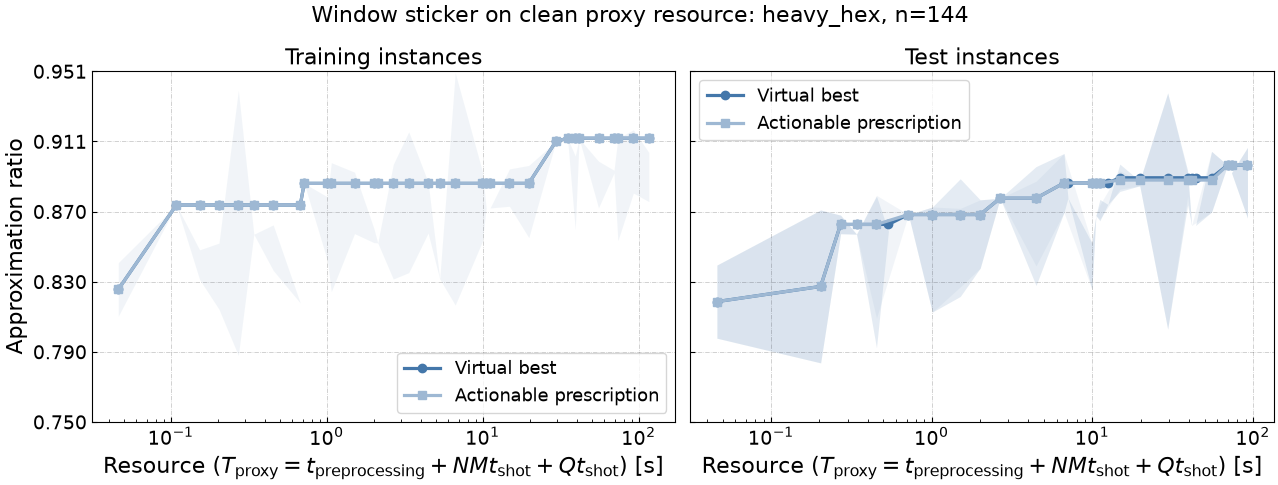

Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/parameter_prescriptions_clean_proxy_resource.pdf and .png


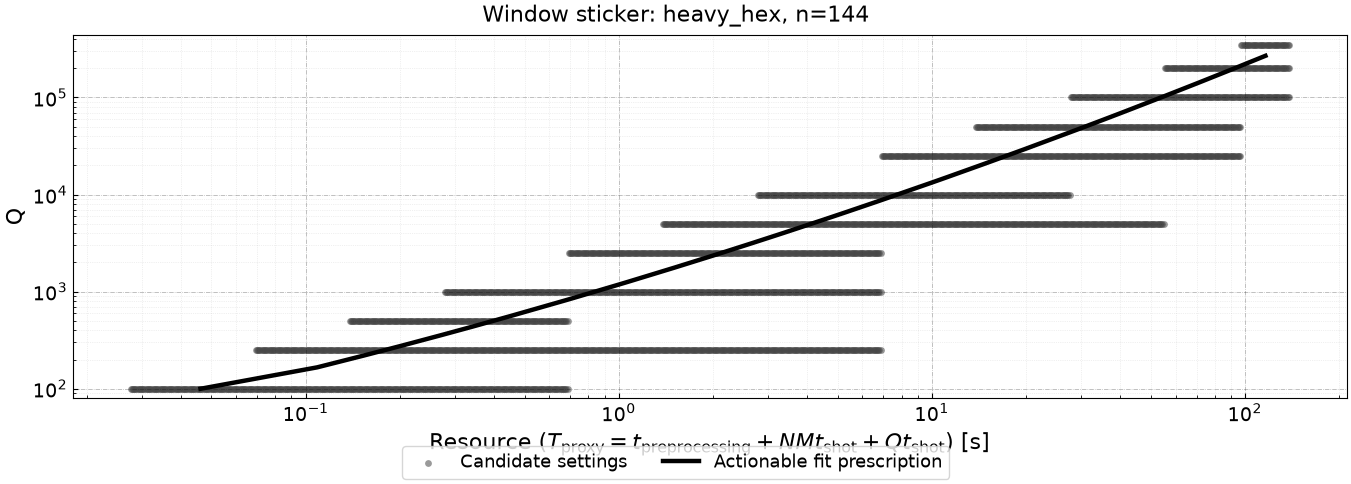

,strategy,T,ApproximationRatio
0,FA_PP_no_opt,0.027579,0.828647
1,FA_PP_no_opt,0.027815,0.828647
2,FA_PP_no_opt,0.028053,0.828647
3,FA_PP_no_opt,0.028293,0.828647
4,FA_PP_no_opt,0.028536,0.828647
...,...,...,...
995,FA_PP_no_opt,133.270934,0.898485
996,FA_PP_no_opt,134.412022,0.898485
997,FA_PP_no_opt,135.562880,0.898485
998,FA_PP_no_opt,136.723592,0.898485


Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/per_method_cost_performance_clean_proxy_resource.pdf and .png


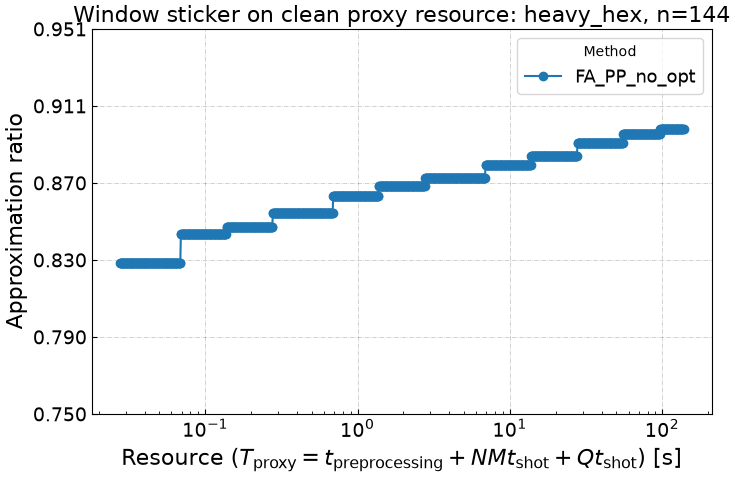

Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/monotone_envelope_comparison_clean_proxy_resource.pdf and .png


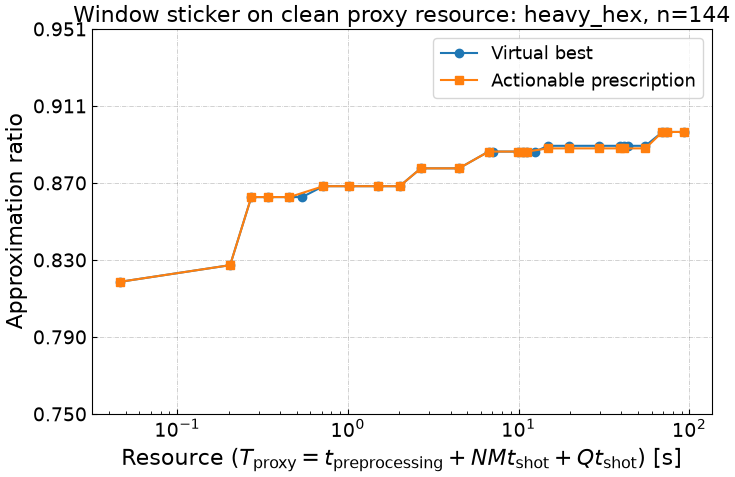

In [7]:
# Active-resource summaries and plots
strategy_budget_df = build_strategy_budget_summary(WS_FRONTIER_DF, split='train')
vb_train_lookup_df = ws_results['vb_train_lookup_df'].copy()
lookup_recipe_train_df = ws_results['recipe_train_df'].copy()
lookup_train_eval_df = ws_results['actionable_train_eval_df'].copy()
fitted_recipe_train_df = ws_results['fitted_recipe_df'].copy()
fitted_train_eval_df = ws_results['fitted_train_eval_df'].copy()
fitted_test_eval_df = ws_results['fitted_test_eval_df'].copy()
fitted_recipe_model_df = ws_results['fitted_recipe_model_df'].copy()
lookup_test_eval_df = window_sticker_summary_df.copy()

best_fitted_df = fitted_test_eval_df.sort_values(['response', 'resource'], ascending=[False, True]).reset_index(drop=True)
recommendation_summary = pd.DataFrame([
    {
        'graph type': GRAPH_TYPE,
        'num nodes': NUM_NODES,
        'resource axis': WS_RESOURCE_AXIS,
        'fitted strategy': best_fitted_df.iloc[0]['strategy'] if not best_fitted_df.empty else None,
        'fitted p': best_fitted_df.iloc[0]['p'] if not best_fitted_df.empty else None,
        'fitted N': best_fitted_df.iloc[0]['N'] if not best_fitted_df.empty else None,
        'fitted M': best_fitted_df.iloc[0]['M'] if not best_fitted_df.empty else None,
        'fitted Q': best_fitted_df.iloc[0]['Q'] if not best_fitted_df.empty else None,
        'fitted response': best_fitted_df.iloc[0]['response'] if not best_fitted_df.empty else None,
    }
])

display(strategy_budget_df.head(20))
display(vb_train_lookup_df.head(20))
display(lookup_recipe_train_df.head(20))
display(fitted_recipe_train_df.head(20))
display(lookup_train_eval_df.head(20))
display(fitted_train_eval_df.head(20))
display(fitted_test_eval_df.head(20))
display(fitted_recipe_model_df)
display(recommendation_summary)

resource_support_debug_df = pd.DataFrame([
    {
        'dataset': f'train {WS_FRONTIER_NAME}',
        'n_rows': len(WS_FRONTIER_DF[WS_FRONTIER_DF['split'].astype(str).eq('train')]),
        'resource_min': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('train'), 'T'].min(),
        'resource_max': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('train'), 'T'].max(),
    },
    {
        'dataset': f'test {WS_FRONTIER_NAME}',
        'n_rows': len(WS_FRONTIER_DF[WS_FRONTIER_DF['split'].astype(str).eq('test')]),
        'resource_min': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('test'), 'T'].min(),
        'resource_max': WS_FRONTIER_DF.loc[WS_FRONTIER_DF['split'].astype(str).eq('test'), 'T'].max(),
    },
    {
        'dataset': 'train virtual-best lookup',
        'n_rows': len(vb_train_lookup_df),
        'resource_min': vb_train_lookup_df['resource'].min() if not vb_train_lookup_df.empty else None,
        'resource_max': vb_train_lookup_df['resource'].max() if not vb_train_lookup_df.empty else None,
    },
    {
        'dataset': 'fitted prescription test',
        'n_rows': len(fitted_test_eval_df),
        'resource_min': fitted_test_eval_df['resource'].min() if not fitted_test_eval_df.empty else None,
        'resource_max': fitted_test_eval_df['resource'].max() if not fitted_test_eval_df.empty else None,
    },
])
display(resource_support_debug_df)

if not fitted_recipe_model_df.empty:
    print(f'Actionable prescription equations on {WS_RESOURCE_AXIS}:')
    for expression in fitted_recipe_model_df['expression'].dropna().tolist():
        print('  ' + expression)

shared_approx_ylim = compute_shared_approx_ylim(
    virtual_best_df.get('response'),
    fitted_test_eval_df.get('response'),
    lookup_test_eval_df.get('response'),
    vb_train_lookup_df.get('response'),
    lookup_train_eval_df.get('response'),
    fitted_train_eval_df.get('response'),
    strategy_budget_df.get('response_mean'),
    WS_FRONTIER_DF.get('BestApproximationRatio'),
)
shared_approx_yticks = compute_shared_approx_yticks(shared_approx_ylim)

train_virtual_best_monotone_df = prepare_monotone_curve(vb_train_lookup_df)
lookup_train_monotone_df = prepare_monotone_curve(lookup_train_eval_df)
fitted_train_monotone_df = prepare_monotone_curve(fitted_train_eval_df)
test_virtual_best_monotone_df = prepare_monotone_curve(virtual_best_df)
lookup_test_monotone_df = prepare_monotone_curve(lookup_test_eval_df)
fitted_test_monotone_df = prepare_monotone_curve(fitted_test_eval_df)

xlabel = WS_XLABEL
exact_ylabel = 'Approximation ratio'
main_title = WS_TITLE
single_method_label = curve_label(strategy_budget_df, RESULT_TAG)
single_method_colors = window_sticker_curve_colors(single_method_label)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_specs = [
    (axes[0], train_virtual_best_monotone_df, fitted_train_monotone_df, lookup_train_monotone_df, 'Training instances'),
    (axes[1], test_virtual_best_monotone_df, fitted_test_monotone_df, lookup_test_monotone_df, 'Test instances'),
]
for ax, vb_curve, fitted_curve, lookup_curve, title in plot_specs:
    for curve, color_key, label, marker, linewidth, alpha in [
        (vb_curve, 'virtual_best', 'Virtual best', 'o', 2.3, 1.0),
        (fitted_curve, 'actionable_prescription', 'Actionable prescription', 's', 2.3, 1.0),
    ]:
        if curve.empty:
            continue
        color = single_method_colors[color_key]
        lower_col = 'response_lower_monotone' if 'response_lower_monotone' in curve.columns else 'response_lower'
        upper_col = 'response_upper_monotone' if 'response_upper_monotone' in curve.columns else 'response_upper'
        if lower_col in curve.columns and upper_col in curve.columns:
            band = curve.dropna(subset=['resource', lower_col, upper_col])
            if not band.empty:
                ax.fill_between(
                    band['resource'].to_numpy(dtype=float),
                    band[lower_col].to_numpy(dtype=float),
                    band[upper_col].to_numpy(dtype=float),
                    color=color,
                    alpha=0.14,
                    linewidth=0,
                    zorder=1,
                )
        if linewidth > 0:
            ax.plot(
                curve['resource'],
                curve['response_monotone'],
                color=color,
                marker=marker,
                linewidth=linewidth,
                label=label,
                zorder=3,
            )
        else:
            ax.scatter(
                curve['resource'],
                curve['response_monotone'],
                color=color,
                marker=marker,
                s=34,
                alpha=alpha,
                label=label,
                zorder=3,
            )
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    apply_shared_approx_axis(ax, ylim=shared_approx_ylim, yticks=shared_approx_yticks)
    ax.legend()
axes[0].set_ylabel(exact_ylabel)
fig.suptitle(main_title)
fig.tight_layout()
save_current_plot(f'cost_vs_best_approximation_ratio_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

active_candidate_parameter_df = WS_FRONTIER_DF[
    WS_FRONTIER_DF['split'].astype(str).eq('train')
].drop_duplicates(['instance', 'N', 'M', 'Q', 'T']).copy()

plot_parameter_prescriptions_by_resource(
    candidate_df=active_candidate_parameter_df,
    virtual_best_df=vb_train_lookup_df,
    lookup_df=lookup_train_eval_df,
    actionable_df=fitted_recipe_train_df,
    candidate_resource_col='T',
    curve_resource_col='resource',
    plot_dir=PLOT_DIR,
    filename=f'parameter_prescriptions_{WS_PLOT_SUFFIX}',
    title=f'Window sticker: {GRAPH_TYPE}, n={NUM_NODES}',
    xlabel=xlabel,
    connect_points=True,
    connect_lookup=False,
    show_virtual_best=False,
    show_lookup=False,
    actionable_marker=None,
)

per_method_curve_df = strategy_budget_df.loc[:, ['strategy', 'T', 'response_mean']].rename(columns={'response_mean': 'ApproximationRatio'})
display(per_method_curve_df)
plt.figure(figsize=(8, 5))
for strategy_name, group in per_method_curve_df.groupby('strategy'):
    plt.plot(group['T'], group['ApproximationRatio'], marker='o', label=strategy_name)
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend(title='Method')
save_current_plot(f'per_method_cost_performance_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(test_virtual_best_monotone_df['resource'], test_virtual_best_monotone_df['response_monotone'], marker='o', label='Virtual best')
plt.plot(fitted_test_monotone_df['resource'], fitted_test_monotone_df['response_monotone'], marker='s', label='Actionable prescription')
plt.xscale('log')
plt.xlabel(xlabel)
plt.ylabel(exact_ylabel)
apply_shared_approx_axis(ylim=shared_approx_ylim, yticks=shared_approx_yticks)
plt.title(main_title)
plt.grid(alpha=0.25)
plt.legend()
save_current_plot(f'monotone_envelope_comparison_{WS_PLOT_SUFFIX}', PLOT_DIR)
plt.show()

## Multi-Strategy Window Sticker Comparison

This section compares completed strategy roots listed in `COMPARISON_RESULT_TAGS`. Each result root must first have its single-strategy Window Sticker summary generated (`window_sticker_summary.csv`). Training summaries are loaded when present and rebuilt from `pss_exp_raw_frontier.pkl` when needed.


Loaded strategy roots:
  Fixed Angles$^\star$ (p=5): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p5_expanded
  Fixed Angles$^\star$ (p=6): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p6_expanded
  Fixed Angles$^\star$ (p=7): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_PP_opt_p7_expanded
  Linear Ramp (p=5): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_LR_opt_p5_expanded
  Interp.$^\star$ (p=7): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_I_p7_expanded
  Param. Transfer (p=7): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p7_expanded
  Param. Transfer (p=6): <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_PT_p6_expanded
  Param. Transfer 

,method_label,strategy,simulation_method,p,T,response_mean,N_mean,M_mean,Q_mean,T_exact_proxy_mean,n_instances,n_candidates
0,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000500,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
1,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000503,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
2,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000507,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
3,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000510,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
4,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000514,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
5,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000517,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
6,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000520,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
7,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000524,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
8,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000527,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0
9,Fixed Angles$^\star$ (p=5),FA_PP_opt,MPSAer,5.0,0.000531,0.817931,10.0,10.0,100.0,0.0005,20.0,20.0


Per-method resource ranges:
                                 min         max
method_label                                    
Fixed Angles$^\star$ (p=5)  0.073852   37.488726
Fixed Angles$^\star$ (p=6)  0.072661   24.641105
Fixed Angles$^\star$ (p=7)  0.080133   47.743056
Fixed Angles† (p=2)         0.045741  114.278956
Fixed Angles† (p=3)         0.045741  114.278956
Fixed Angles† (p=4)         0.045741  114.278956
Fixed Angles† (p=6)         0.046132  116.163644
Interp.$^\star$ (p=7)       0.959622  128.415034
Linear Ramp (p=5)           0.070595   34.011838
Param. Transfer (p=2)       0.053165   77.496237
Param. Transfer (p=3)       0.047412   81.463301
Param. Transfer (p=5)       0.055905   84.244581
Param. Transfer (p=6)       0.053056   82.826755
Param. Transfer (p=7)       0.058620   89.806244

Data-driven xlim: (0.9596, 24.64) s
Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/multi_method_wi

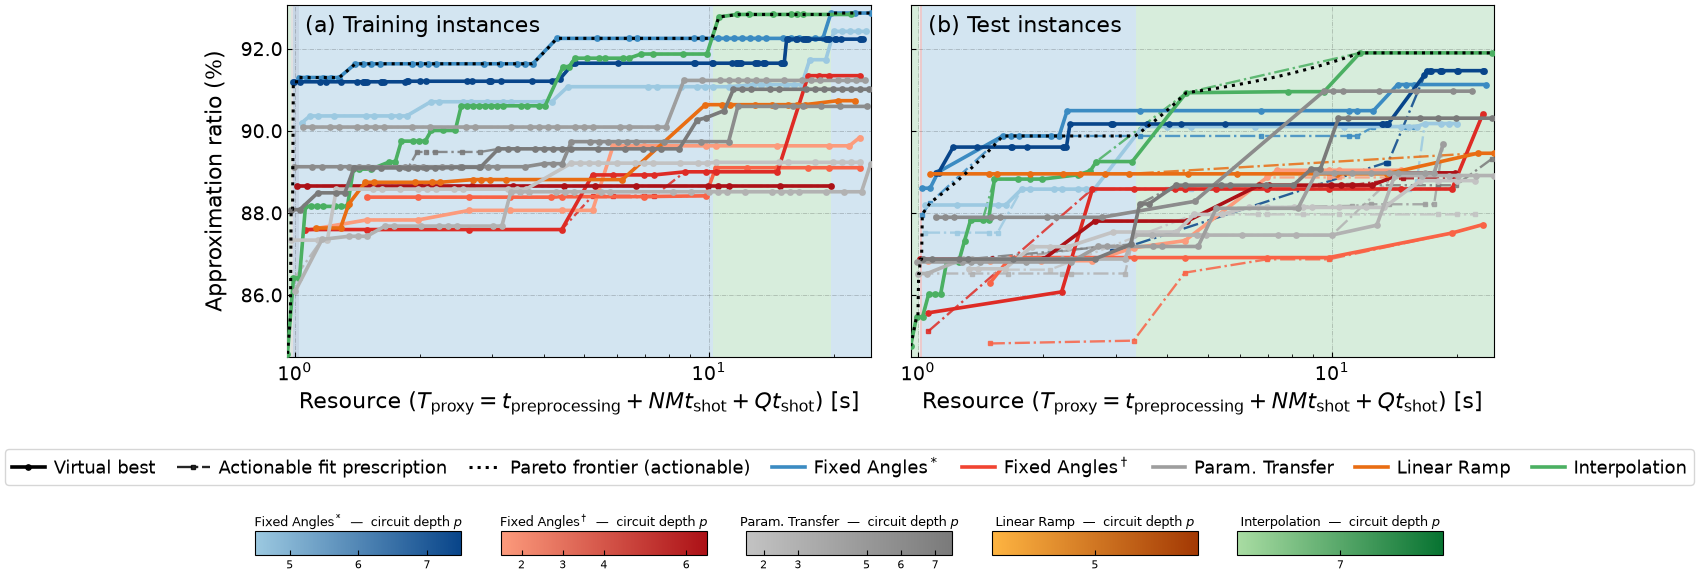

In [8]:
# Multi-strategy actionable PSS comparison
# Add future strategy result tags here after those campaigns finish.
MULTI_STRATEGY_RESULT_TAGS = list(COMPARISON_RESULT_TAGS)

PSS_RESULTS_BASE = OUTPUT_ROOT.parent

required_summary_files = ['window_sticker_summary.csv']
missing_summary_files = []
for tag in MULTI_STRATEGY_RESULT_TAGS:
    root = PSS_RESULTS_BASE / tag
    for filename in required_summary_files:
        if not (root / filename).exists():
            missing_summary_files.append(root / filename)
if missing_summary_files:
    print('Missing Window Sticker summary files for multi-strategy comparison:')
    for path in missing_summary_files:
        print(f'  {path}')
    if SKIP_MISSING_MULTI_STRATEGY_SUMMARIES:
        missing_tags = {path.parent.name for path in missing_summary_files}
        MULTI_STRATEGY_RESULT_TAGS = [
            tag for tag in MULTI_STRATEGY_RESULT_TAGS if tag not in missing_tags
        ]
        print('Skipping unfinished strategy roots:', sorted(missing_tags))
    else:
        raise FileNotFoundError(
            'Generate the missing single-strategy Window Sticker summary first. '
            'For a new strategy, rerun its load + Window Sticker cells once.'
        )

multi_strategy_summaries = load_multi_strategy_summaries(MULTI_STRATEGY_RESULT_TAGS, PSS_RESULTS_BASE)
print('Loaded strategy roots:')
for item in multi_strategy_summaries:
    print(f"  {item['method_label']}: {item['root']}")

multi_strategy_budget_df = concat_summary(multi_strategy_summaries, 'strategy_budget')
multi_actionable_lookup_df = concat_summary(multi_strategy_summaries, 'actionable_lookup')
multi_actionable_fit_df = concat_summary(multi_strategy_summaries, 'actionable_fit')
multi_window_sticker_df = concat_summary(multi_strategy_summaries, 'window_sticker')
multi_virtual_best_df = concat_summary(multi_strategy_summaries, 'virtual_best')
multi_virtual_best_train_df = concat_summary(multi_strategy_summaries, 'virtual_best_train')
multi_fitted_projection_train_df = concat_summary(multi_strategy_summaries, 'fitted_projection_train')
multi_fitted_projection_test_df = concat_summary(multi_strategy_summaries, 'fitted_projection_test')

training_strategy_curve_df = curve_from_training_summary(multi_strategy_budget_df)
training_virtual_best_component_cols = [
    col for col in [
        'method_label', 'T', 'response_monotone',
        'response_lower_monotone', 'response_upper_monotone',
    ]
    if col in training_strategy_curve_df.columns
]
training_virtual_best_components_df = training_strategy_curve_df.loc[
    :, training_virtual_best_component_cols
].rename(
    columns={
        'T': 'resource',
        'response_monotone': 'response',
        'response_lower_monotone': 'response_lower',
        'response_upper_monotone': 'response_upper',
    }
)
training_strategy_envelope_df = cross_strategy_envelope(training_strategy_curve_df, 'T')

actionable_projection_curve_df = curve_from_window_summary(multi_window_sticker_df)
actionable_projection_envelope_df = cross_strategy_envelope(actionable_projection_curve_df, 'resource')

# This table is the direct answer to: which hyperparameters define the strategy curve at each budget?
hyperparameter_lookup_cols = [
    col for col in [
        'method_label', 'strategy', 'simulation_method', 'p', 'T', 'response_mean',
        'N_mean', 'M_mean', 'Q_mean', 'T_exact_proxy_mean', 'n_instances', 'n_candidates',
    ]
    if col in multi_actionable_lookup_df.columns
]
hyperparameter_lookup_df = multi_actionable_lookup_df.loc[:, hyperparameter_lookup_cols].copy() if hyperparameter_lookup_cols else pd.DataFrame()

if not hyperparameter_lookup_df.empty:
    hyperparameter_lookup_df.to_csv(OUTPUT_ROOT / 'multi_strategy_hyperparameter_lookup.csv', index=False)
if not training_strategy_envelope_df.empty:
    training_strategy_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_training_envelope.csv', index=False)
if not actionable_projection_envelope_df.empty:
    actionable_projection_envelope_df.to_csv(OUTPUT_ROOT / 'multi_strategy_actionable_projection_envelope.csv', index=False)

print('Hyperparameter lookup rows:', len(hyperparameter_lookup_df))
display(hyperparameter_lookup_df.head(20))

# Refresh plotting helper to avoid stale notebook/autoreload function objects.
import importlib
from src import utils as ibm_qaoa_plot_utils
ibm_qaoa_plot_utils = importlib.reload(ibm_qaoa_plot_utils)
plot_multi_method_window_sticker_component_panels = ibm_qaoa_plot_utils.plot_multi_method_window_sticker_component_panels

# Data-driven xlim: intersection of all methods' resource ranges so every curve
# starts and ends at the same plot boundary (tightest common window).
_all_curves = pd.concat(
    [df for df in [
        multi_virtual_best_df, multi_virtual_best_train_df,
        multi_fitted_projection_test_df, multi_fitted_projection_train_df,
    ] if not df.empty and 'resource' in df.columns and 'method_label' in df.columns],
    ignore_index=True,
)
_all_curves['resource'] = pd.to_numeric(_all_curves['resource'], errors='coerce')
_all_curves = _all_curves[_all_curves['resource'] > 0].dropna(subset=['resource'])
_per_method = _all_curves.groupby('method_label')['resource'].agg(['min', 'max'])
_xlim_left = float(_per_method['min'].max())   # latest start across all methods
_xlim_right = float(_per_method['max'].min())  # earliest end across all methods
print(f'Per-method resource ranges:\n{_per_method.to_string()}')
print(f'\nData-driven xlim: ({_xlim_left:.4g}, {_xlim_right:.4g}) s')
MULTI_METHOD_XLIM = (_xlim_left, _xlim_right) if _xlim_left < _xlim_right else None

plot_multi_method_window_sticker_component_panels(
    training_virtual_best_df=multi_virtual_best_train_df,
    training_fitted_prescription_df=multi_fitted_projection_train_df,
    test_virtual_best_df=multi_virtual_best_df,
    test_fitted_prescription_df=multi_fitted_projection_test_df,
    filename='multi_method_window_sticker_component_panels',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
    show_ci=SHOW_WINDOW_STICKER_CI,
    xlim=MULTI_METHOD_XLIM,
)


## Hardware-Calibrated Multi-Strategy Window Sticker

Re-calibrates the x-axis using the **actual IBM hardware shot rate** measured in arXiv:2606.05311v1, rather than per-shot timing extracted from hardware JSON files.

Two versions are produced via **post-hoc rescaling** of the existing window-sticker summary files (no PSS re-run needed). Each method's resource values are multiplied by $t_{\text{shot,new}}(p)\,/\,t_{\text{shot,hw}}(p)$, where $t_{\text{shot,hw}}$ comes from the local hardware timing JSONs.

| Version | $t_{\text{shot}}$ | Description |
|---------|-------------------|-------------|
| **Noiseless** | $1/2470\,\text{Hz} \approx 405\,\mu\text{s}$ | Paper-measured wall-clock rate on ibm\_boston; samples treated as noiseless |
| **Noise-corrected** | $t_{\text{noiseless}}/\sqrt{\gamma}$ | Need $1/\sqrt{\gamma}$ more shots to get one effective noiseless-equivalent sample |

$$\sqrt{\gamma}(p) = F_{\text{CZ}}^{\,N_{\text{CZ}}/2}, \quad N_{\text{CZ}} = 2 \times 143 \times p$$

$F_{\text{CZ}} = 99.872\%$ (ibm\_boston median CZ fidelity, App. G2 of the paper). The correction is **depth-dependent**: higher-$p$ methods are penalised more. Note: the PT classical preprocessing time is also rescaled (it is small relative to sampling cost and the approximation is negligible).


In [9]:
# ── Hardware calibration parameters (arXiv:2606.05311v1) ─────────────────────
# Paper measures 2.47 kHz wall-clock shot rate on ibm_boston (Sec. III B 1).
# F_CZ = 99.872% = ibm_boston median CZ-gate fidelity (App. G2).
# Heavy-hex 144-qubit device has 143 hardware-native coupling edges (no SWAPs).
# One QAOA layer at depth p uses N_CZ = 2 × 143 × p two-qubit gates.
# Noise correction: sqrt(gamma) = F_CZ^(N_CZ / 2) effective samples per raw shot.
# Noise-corrected effective t_shot = t_shot_noiseless / sqrt(gamma).

PAPER_SHOT_RATE_HZ = 2_470
F_CZ = 1.0 - 0.00128
HEAVY_HEX_144_EDGES = 143

# Hardware-derived t_shot per depth from local timing JSONs (fallback = p=7 median)
_hw_t_shot_by_p = {}
for _p in range(1, 11):
    try:
        _hw_t_shot_by_p[_p] = estimate_hardware_time_per_shot(
            HARDWARE_RESULTS_ROOT,
            graph_type=GRAPH_TYPE,
            num_nodes=NUM_NODES,
            job_p=_p,
            statistic='median',
            normalize_by_pubs=True,
        )
    except (FileNotFoundError, ValueError):
        _hw_t_shot_by_p[_p] = TIME_PER_SHOT  # no JSON for this p → use p=7 fallback

_t_noiseless = 1.0 / PAPER_SHOT_RATE_HZ
_t_calib_noiseless = {p: _t_noiseless for p in range(1, 11)}
_t_calib_noise_corrected = {}
_sqrt_gamma_by_p = {}

for _p in range(1, 11):
    _n_cz = 2 * HEAVY_HEX_144_EDGES * _p
    _sg = F_CZ ** (_n_cz / 2.0)
    _sqrt_gamma_by_p[_p] = _sg
    _t_calib_noise_corrected[_p] = _t_noiseless / _sg

calib_table_df = pd.DataFrame([
    {
        'p': _p,
        't_hw_us':          _hw_t_shot_by_p[_p] * 1e6,
        'N_CZ':             2 * HEAVY_HEX_144_EDGES * _p,
        'sqrt_gamma':       _sqrt_gamma_by_p[_p],
        't_noiseless_us':   _t_calib_noiseless[_p] * 1e6,
        't_noise_corr_us':  _t_calib_noise_corrected[_p] * 1e6,
        'scale_noiseless':  _t_calib_noiseless[_p]       / _hw_t_shot_by_p[_p],
        'scale_noise_corr': _t_calib_noise_corrected[_p] / _hw_t_shot_by_p[_p],
    }
    for _p in range(1, 11)
])
print(f'Paper shot rate: {PAPER_SHOT_RATE_HZ} Hz  →  t_noiseless = {_t_noiseless*1e6:.1f} μs/shot')
print(f'F_CZ = {F_CZ:.5f},  heavy-hex 144 edges = {HEAVY_HEX_144_EDGES}')
display(calib_table_df)


Paper shot rate: 2470 Hz  →  t_noiseless = 404.9 μs/shot
F_CZ = 0.99872,  heavy-hex 144 edges = 143


,p,t_hw_us,N_CZ,sqrt_gamma,t_noiseless_us,t_noise_corr_us,scale_noiseless,scale_noise_corr
0,1,275.788484,286,0.832637,404.8583,486.236132,1.468003,1.763076
1,2,271.267361,572,0.693285,404.8583,583.971173,1.492470,2.152751
2,3,271.267361,858,0.577255,404.8583,701.351274,1.492470,2.585461
3,4,271.267361,1144,0.480644,404.8583,842.325156,1.492470,3.105147
4,5,280.309606,1430,0.400202,404.8583,1011.635247,1.444325,3.608992
5,6,275.788484,1716,0.333223,404.8583,1214.977215,1.468003,4.405468
6,7,298.394097,2002,0.277454,404.8583,1459.191578,1.356791,4.890149
7,8,280.309606,2288,0.231018,404.8583,1752.493822,1.444325,6.251993
8,9,271.267361,2574,0.192355,404.8583,2104.750768,1.492470,7.758953
9,10,280.309606,2860,0.160162,404.8583,2527.812504,1.444325,9.017930


In [10]:
# ── Post-hoc resource rescaling ───────────────────────────────────────────────
# Build method_label → p from the already-loaded multi_strategy_summaries
_label_to_p = {}
for _item in multi_strategy_summaries:
    _root_name = Path(_item['root']).name
    _pm = re.search(r'_p(\d+)', _root_name)
    if _pm:
        _label_to_p[_item['method_label']] = int(_pm.group(1))

# Scale factors: (t_shot_new[p]) / (t_shot_hardware[p])
_sf_noiseless = {
    lbl: _t_calib_noiseless[p] / _hw_t_shot_by_p.get(p, TIME_PER_SHOT)
    for lbl, p in _label_to_p.items()
}
_sf_noise_corrected = {
    lbl: _t_calib_noise_corrected[p] / _hw_t_shot_by_p.get(p, TIME_PER_SHOT)
    for lbl, p in _label_to_p.items()
}

print('Scale factors (noiseless, noise-corrected) by method:')
for lbl in sorted(_sf_noiseless):
    p = _label_to_p[lbl]
    print(f'  p={p}  {lbl:45s}  ×{_sf_noiseless[lbl]:.3f}  ×{_sf_noise_corrected[lbl]:.3f}')

def _rescale_resource(df, scale_by_label):
    """Multiply 'resource' column by per-method_label scale factor."""
    if df is None or df.empty or 'resource' not in df.columns:
        return (df if df is not None else pd.DataFrame()).copy()
    df = df.copy()
    if 'method_label' in df.columns:
        for lbl, factor in scale_by_label.items():
            mask = df['method_label'] == lbl
            df.loc[mask, 'resource'] = df.loc[mask, 'resource'] * factor
    return df

# Noiseless-calibrated versions (2.47 kHz, raw samples assumed perfect)
calib_nl_vb_train_df      = _rescale_resource(multi_virtual_best_train_df,       _sf_noiseless)
calib_nl_fit_train_df     = _rescale_resource(multi_fitted_projection_train_df,   _sf_noiseless)
calib_nl_vb_test_df       = _rescale_resource(multi_virtual_best_df,              _sf_noiseless)
calib_nl_fit_test_df      = _rescale_resource(multi_fitted_projection_test_df,    _sf_noiseless)

# Noise-corrected versions (2.47 kHz × sqrt(gamma), depth-dependent)
calib_nc_vb_train_df      = _rescale_resource(multi_virtual_best_train_df,       _sf_noise_corrected)
calib_nc_fit_train_df     = _rescale_resource(multi_fitted_projection_train_df,   _sf_noise_corrected)
calib_nc_vb_test_df       = _rescale_resource(multi_virtual_best_df,              _sf_noise_corrected)
calib_nc_fit_test_df      = _rescale_resource(multi_fitted_projection_test_df,    _sf_noise_corrected)


Scale factors (noiseless, noise-corrected) by method:
  p=5  Fixed Angles$^\star$ (p=5)                     ×1.444  ×3.609
  p=6  Fixed Angles$^\star$ (p=6)                     ×1.468  ×4.405
  p=7  Fixed Angles$^\star$ (p=7)                     ×1.357  ×4.890
  p=2  Fixed Angles† (p=2)                            ×1.492  ×2.153
  p=3  Fixed Angles† (p=3)                            ×1.492  ×2.585
  p=4  Fixed Angles† (p=4)                            ×1.492  ×3.105
  p=6  Fixed Angles† (p=6)                            ×1.468  ×4.405
  p=7  Interp.$^\star$ (p=7)                          ×1.357  ×4.890
  p=5  Linear Ramp (p=5)                              ×1.444  ×3.609
  p=2  Param. Transfer (p=2)                          ×1.492  ×2.153
  p=3  Param. Transfer (p=3)                          ×1.492  ×2.585
  p=5  Param. Transfer (p=5)                          ×1.444  ×3.609
  p=6  Param. Transfer (p=6)                          ×1.468  ×4.405
  p=7  Param. Transfer (p=7)                     

Noiseless calibrated xlim: (0.06772215432974114, 174.232307891543)
Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/multi_method_window_sticker_hw_noiseless.pdf and .png


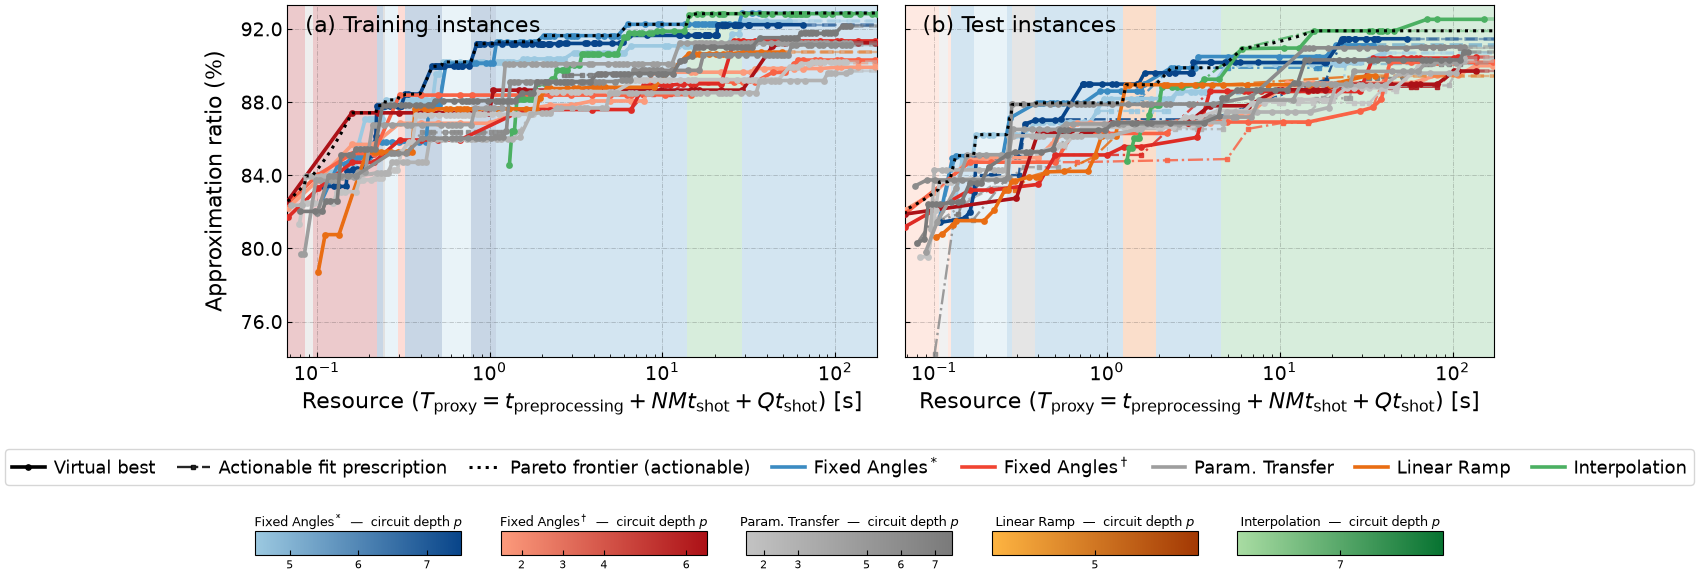

In [11]:
# ── Noiseless calibrated plot (2.47 kHz hardware rate, raw samples) ──────────
_all_nl = pd.concat(
    [df for df in [calib_nl_vb_test_df, calib_nl_vb_train_df,
                   calib_nl_fit_test_df, calib_nl_fit_train_df]
     if not df.empty and 'resource' in df.columns and 'method_label' in df.columns],
    ignore_index=True,
)
_all_nl['resource'] = pd.to_numeric(_all_nl['resource'], errors='coerce')
_all_nl = _all_nl[_all_nl['resource'] > 0].dropna(subset=['resource'])
_per_nl = _all_nl.groupby('method_label')['resource'].agg(['min', 'max'])
# Full union of all method ranges; curves hold their last value to the right edge.
_xl_left_nl = float(_per_nl['min'].min())
_xl_right_nl = float(_per_nl['max'].max())
MULTI_METHOD_XLIM_NOISELESS = (_xl_left_nl, _xl_right_nl) if _xl_left_nl < _xl_right_nl else None
print(f'Noiseless calibrated xlim: {MULTI_METHOD_XLIM_NOISELESS}')

plot_multi_method_window_sticker_component_panels(
    training_virtual_best_df=calib_nl_vb_train_df,
    training_fitted_prescription_df=calib_nl_fit_train_df,
    test_virtual_best_df=calib_nl_vb_test_df,
    test_fitted_prescription_df=calib_nl_fit_test_df,
    filename='multi_method_window_sticker_hw_noiseless',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
    show_ci=SHOW_WINDOW_STICKER_CI,
    xlim=MULTI_METHOD_XLIM_NOISELESS,
    extend_curves_to_xlim=True,
)


Noise-corrected xlim: (0.09846947776711265, 627.9686414372308)
Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/multi_method_window_sticker_hw_noise_corrected.pdf and .png


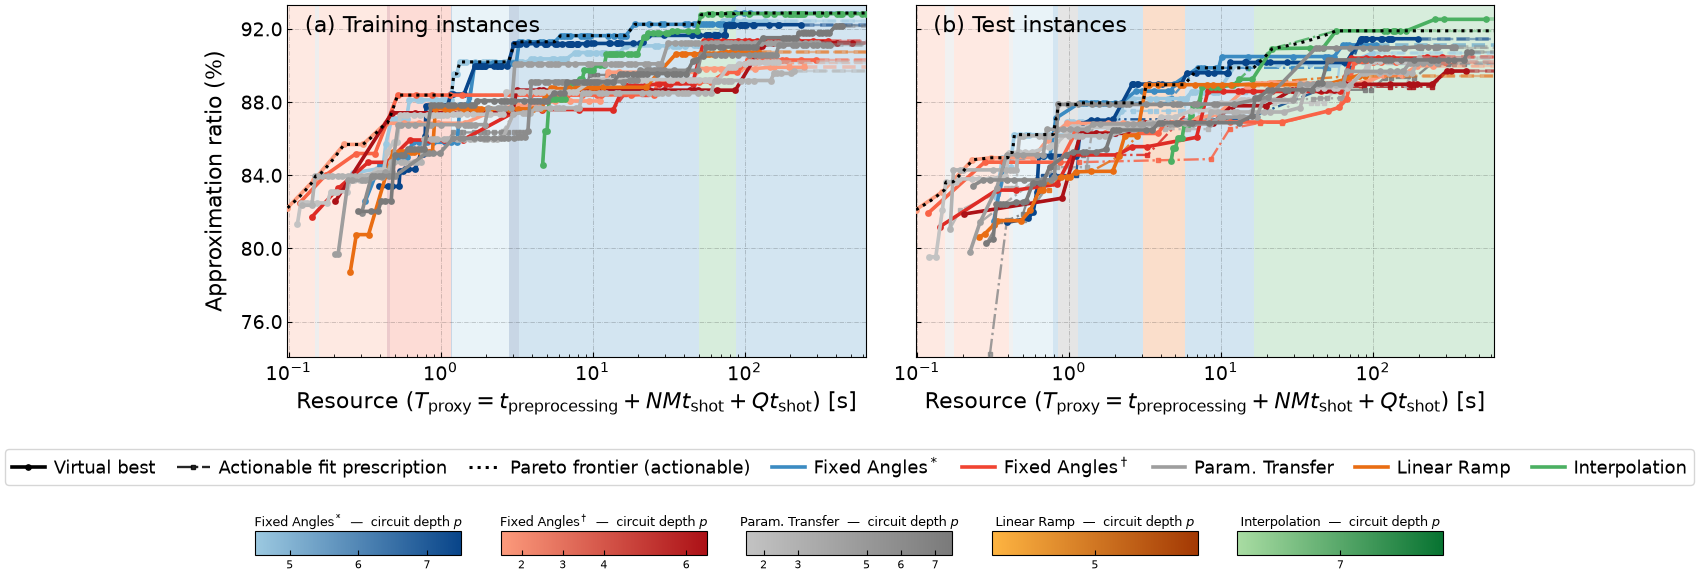

In [12]:
# ── Noise-corrected calibrated plot (2.47 kHz × sqrt(gamma) per circuit depth) ──
_all_nc = pd.concat(
    [df for df in [calib_nc_vb_test_df, calib_nc_vb_train_df,
                   calib_nc_fit_test_df, calib_nc_fit_train_df]
     if not df.empty and 'resource' in df.columns and 'method_label' in df.columns],
    ignore_index=True,
)
_all_nc['resource'] = pd.to_numeric(_all_nc['resource'], errors='coerce')
_all_nc = _all_nc[_all_nc['resource'] > 0].dropna(subset=['resource'])
_per_nc = _all_nc.groupby('method_label')['resource'].agg(['min', 'max'])
# Full union of all method ranges; curves hold their last value to the right edge.
_xl_left_nc = float(_per_nc['min'].min())
_xl_right_nc = float(_per_nc['max'].max())
MULTI_METHOD_XLIM_NOISE_CORRECTED = (_xl_left_nc, _xl_right_nc) if _xl_left_nc < _xl_right_nc else None
print(f'Noise-corrected xlim: {MULTI_METHOD_XLIM_NOISE_CORRECTED}')

plot_multi_method_window_sticker_component_panels(
    training_virtual_best_df=calib_nc_vb_train_df,
    training_fitted_prescription_df=calib_nc_fit_train_df,
    test_virtual_best_df=calib_nc_vb_test_df,
    test_fitted_prescription_df=calib_nc_fit_test_df,
    filename='multi_method_window_sticker_hw_noise_corrected',
    plot_dir=PLOT_DIR,
    approx_ylim=shared_approx_ylim,
    approx_yticks=shared_approx_yticks,
    show_ci=SHOW_WINDOW_STICKER_CI,
    xlim=MULTI_METHOD_XLIM_NOISE_CORRECTED,
    extend_curves_to_xlim=True,
)


## Pareto Frontier Overlay: Hardware Calibrations

Overlays the actionable Pareto frontier (the best currently-deployable strategy at each resource budget) from the noiseless and noise-corrected calibrations on a single axis. Line colour indicates which method family holds the frontier at that resource level (matching the family colours above); linestyle distinguishes the calibration (solid = noiseless, dashed = noise-corrected). This makes the effect of the hardware noise assumption on the recommended strategy and its resource cost visible directly, without having to compare separate figures.

Saved: <workspace>/stochastic-benchmark/examples/IBM_QAOA/results/pss_window_sticker/heavy_hex_144_FA_no_opt_p6_expanded/notebook_plots/pareto_frontier_overlay_hw_calibrations.pdf and .png


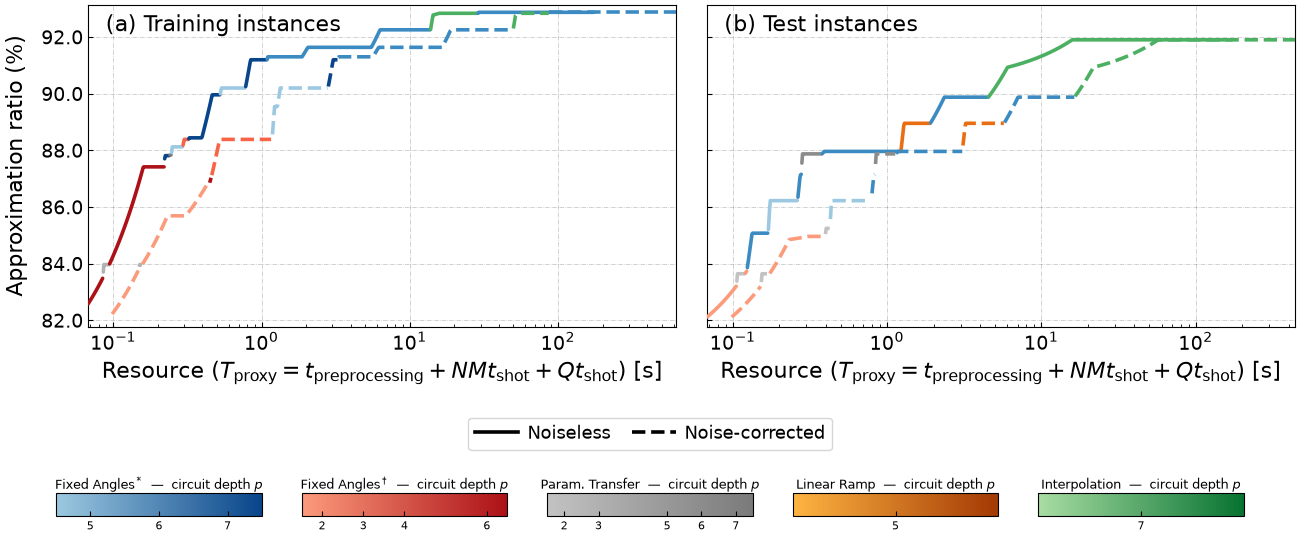

In [13]:
# ── Pareto frontier overlay: noiseless vs. noise-corrected, colour-coded by strategy ──
import importlib
from src import utils as ibm_qaoa_plot_utils
ibm_qaoa_plot_utils = importlib.reload(ibm_qaoa_plot_utils)
plot_pareto_frontier_overlay = ibm_qaoa_plot_utils.plot_pareto_frontier_overlay

plot_pareto_frontier_overlay(
    calibrations=[
        {
            'label': 'Noiseless',
            'linestyle': '-',
            'training_fitted_prescription_df': calib_nl_fit_train_df,
            'test_fitted_prescription_df': calib_nl_fit_test_df,
        },
        {
            'label': 'Noise-corrected',
            'linestyle': '--',
            'training_fitted_prescription_df': calib_nc_fit_train_df,
            'test_fitted_prescription_df': calib_nc_fit_test_df,
        },
    ],
    filename='pareto_frontier_overlay_hw_calibrations',
    plot_dir=PLOT_DIR,
)